## Mall Customer Segmentation Analysis using K-Means Clustering

---

## Executive Summary

This analysis segments mall customers into **5 distinct groups** based on Age, Annual Income, and Spending Score. Key findings:

- **Income does NOT predict spending**: High earners may spend little; low earners may spend heavily.
- **Age creates clear divisions**: Older vs. younger customers have fundamentally different behaviors.
- **Cluster 2 (Affluent Professionals)** is the revenue driver—highest income and spending combined.
- **Cluster 3 (Young Enthusiasts)** represents growth potential but carries over-extension risk.
- **Cluster 5 (Selective Splurgers)** earns the most but spends the least—requires investigation.

---


### Package Importation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

#models for customer segmentation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### Importing dataset

In [3]:
mall = pd.read_csv('Mall_Customers.csv')
mall.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Data cleaning & EDA

In [5]:
eda_overview = pd.DataFrame({
    'Data Type': mall.dtypes,
    'Missing Values': mall.isnull().sum(),
    'Unique Values': mall.nunique(),
    'length': len(mall)
})  


eda_overview

,Data Type,Missing Values,Unique Values,length
CustomerID,int64,0,200,200
Gender,object,0,2,200
Age,int64,0,51,200
Annual Income (k$),int64,0,64,200
Spending Score (1-100),int64,0,84,200


In [7]:
for col in mall.columns:
    if mall[col].dtype == 'object':
        print(f"Unique values for {col}:\n{mall[col].unique()}\n")

Unique values for Gender:
['Male' 'Female']



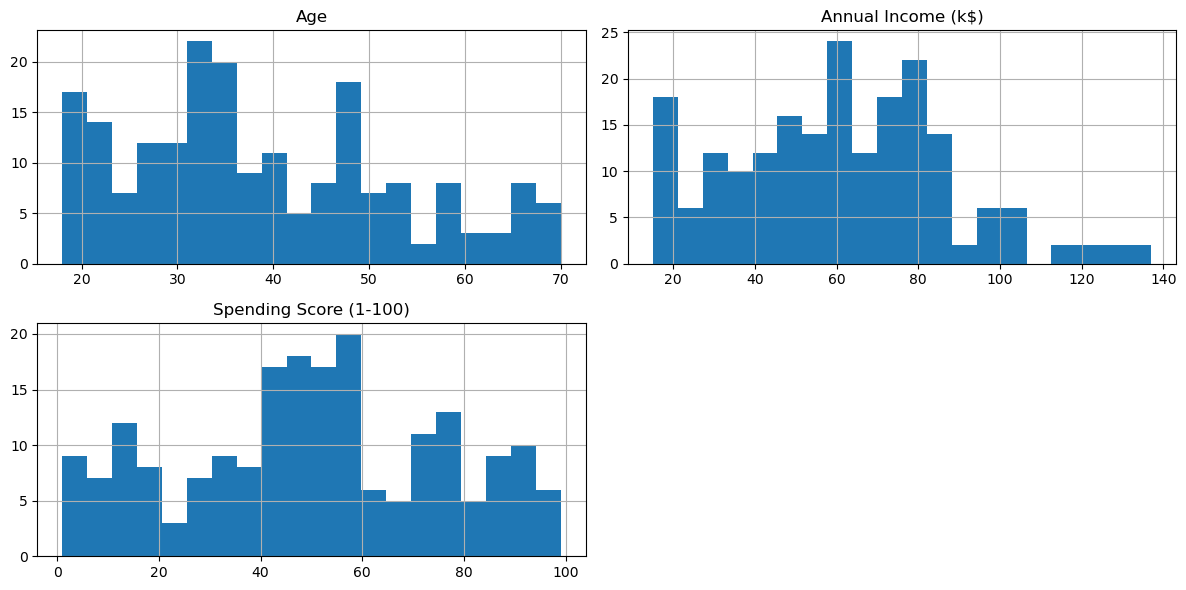

In [8]:
#getting distributions of numerical features
numerical_features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
mall[numerical_features].hist(bins=20, figsize=(12, 6))
plt.tight_layout()
plt.title('Distribution of Numerical Features')
plt.show()


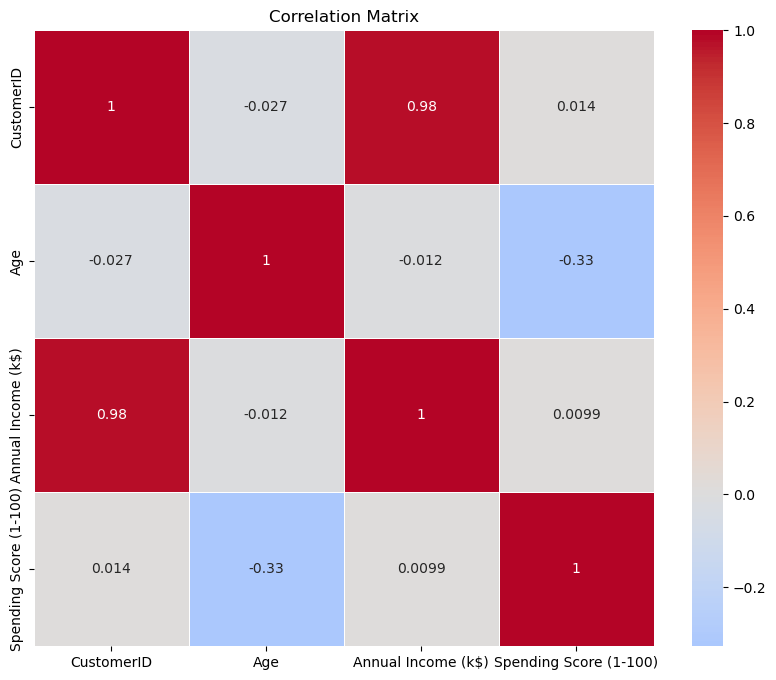

In [9]:
#getting correlation matrix for numerical features
mall_numeric = mall.select_dtypes(include=[np.number])
eda_correlation = mall_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(eda_correlation, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

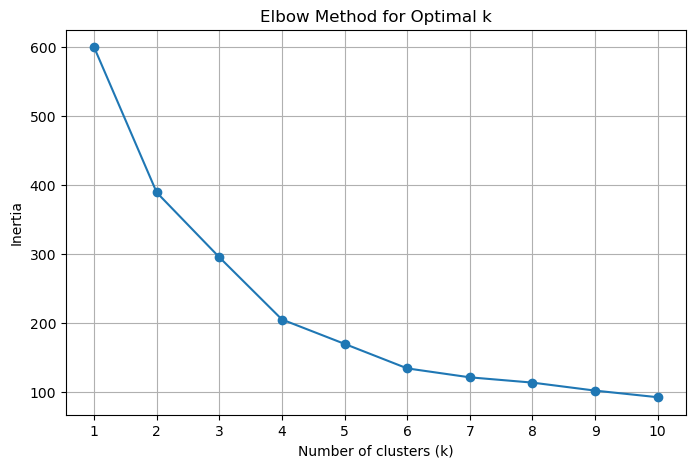

In [13]:
#elbow method to determine optimal number of clusters
X = mall_numeric.drop('CustomerID', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid()
plt.show()

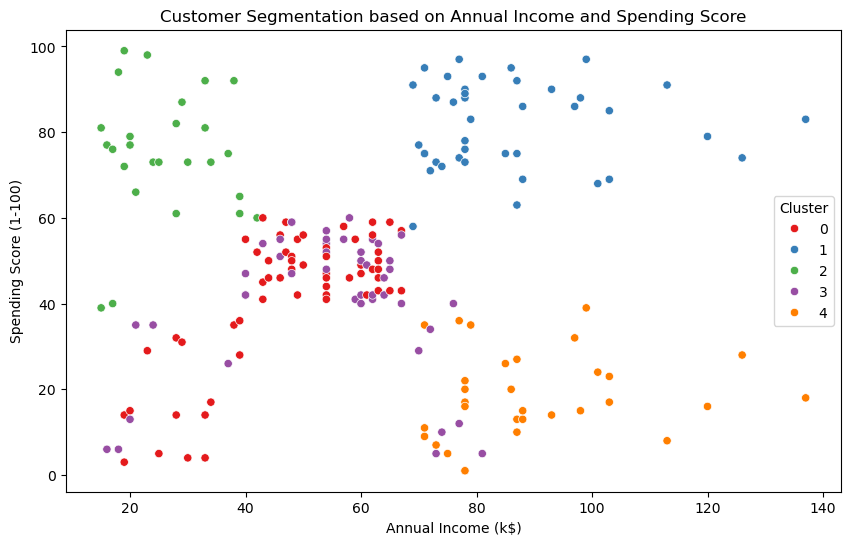

In [14]:
#plotting with ideal balance at elbow, k=5
kmeans = KMeans(n_clusters=5, random_state=42)
mall['Cluster'] = kmeans.fit_predict(X_scaled)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=mall, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='Set1')
plt.title('Customer Segmentation based on Annual Income and Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()

In [20]:
#naming and profiling clusters, don't start from 0, start from 1 for better readability
mall['Cluster'] = mall['Cluster'] + 1
cluster_profiles = mall.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
cluster_profiles['Count'] = mall['Cluster'].value_counts().sort_index()
print(cluster_profiles)

               Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                              
1        55.275862           47.620690               41.706897     58
2        32.875000           86.100000               81.525000     40
3        25.769231           26.115385               74.846154     26
4        26.733333           54.311111               40.911111     45
5        44.387097           89.774194               18.483871     31



## Customer Profiling: 
 The 5 Customer Segments

### Cluster 1: Steady Retirees
**Size**: 58 customers (32% of base)

| Metric | Value |
|--------|-------|
| **Age** | 55 years |
| **Annual Income** | 47.6k GHS |
| **Spending Score** | 41.7 / 100 |

**Profile**: Older, modest income, moderate spending. Budget-conscious value-seekers.

**Key Behaviors**:
- Price-sensitive; attracted to discounts and sales
- Likely seeking practicality (groceries, household essentials)
- May have mobility or comfort considerations

**Business Actions**:
- Anchor tenants focused on **grocery, pharmacy, established brands**
- Promote **discount retailers and sales events**
- Invest in **comfort**: seating areas, accessible parking, clear wayfinding
- Bundle deals on essentials to drive frequency

**Revenue Potential**: Moderate | **Retention Focus**: High (stable, loyal segment)

---

### Cluster 2: Affluent Professionals ⭐
**Size**: 40 customers (22% of base)

| Metric | Value |
|--------|-------|
| **Age** | 33 years |
| **Annual Income** | 86.1k GHS |
| **Spending Score** | 81.5 / 100 (HIGHEST) |

**Profile**: Young, high earners, high spenders. Your **premium revenue segment**.

**Key Behaviors**:
- Spending is driven by quality, status, and premium experience
- Willing to pay for convenience and exclusivity
- Likely shopping for fashion, tech, lifestyle, dining
- Value personalization and premium service

**Business Actions**:
- **Premium brands and luxury tenants** (high-end fashion, jewelry, electronics, fine dining)
- **VIP services**: Priority parking, lounge access, concierge
- **Personalized offers and exclusive events** (members-only sales, new brand launches)
- High-touch customer experience (staff training, curated recommendations)

**Revenue Potential**: **HIGHEST per customer** | **Retention Focus**: Critical (prioritize satisfaction)

---

### Cluster 3: Young Enthusiasts 🔥
**Size**: 26 customers (14% of base)

| Metric | Value |
|--------|-------|
| **Age** | 26 years |
| **Annual Income** | 26.1k GHS (LOWEST) |
| **Spending Score** | 74.8 / 100 (2nd HIGHEST) |

**Profile**: Youngest segment, lowest income, but spending far beyond their means. **Trend and fashion-driven.**

**Key Behaviors**:
- Aspirational—willing to spend on trends, brands, status symbols
- Social media savvy; influenced by trends and peer behavior
- Entertainment and social experience matter (not just products)
- May be vulnerable to over-spending; likely using installment plans or credit

**Business Actions**:
- **Fast fashion and trendy brands** (H&M, Zara, fashion-forward retailers)
- **Social media marketing**: Instagram-worthy spaces, influencer partnerships, TikTok campaigns
- **Affordable luxury**: Payment plans, installment options, affordable brands that feel premium
- **Experience-driven spaces**: Photo zones, events, live music, social gathering areas
- **Community building**: Loyalty programs to build repeat visits and manage over-spending

**Revenue Potential**: High | **Retention Focus**: Critical (engagement + financial responsibility messaging)

**⚠️ Risk Alert**: Monitor for over-extension; opportunity for financial education partnerships.

---

### Cluster 4: Practical Young Professionals
**Size**: 45 customers (25% of base)

| Metric | Value |
|--------|-------|
| **Age** | 27 years |
| **Annual Income** | 54.3k GHS |
| **Spending Score** | 40.9 / 100 |

**Profile**: Young, moderate income, rational and value-conscious. **Budget-aware but engaged.**

**Key Behaviors**:
- Price-sensitive; compare value across options
- Willing to visit mall for quality at fair prices
- Likely seeking mix: shopping, dining, entertainment
- Practical—spend on needs with some wants

**Business Actions**:
- **Mid-range retailers** (H&M, Zara, Jumia, mid-tier restaurants)
- **Loyalty discounts and bundle deals**: Buy 2, get 20% off; combo meals
- **F&B and entertainment mix** to increase visit frequency (why: break up shopping with dining/fun)
- **Flash sales and weekly promotions** (email, SMS)
- Cross-promotions between retailers to increase basket size

**Revenue Potential**: Moderate | **Retention Focus**: High (frequency driver; growing segment potential)

---

### Cluster 5: Selective Splurgers
**Size**: 31 customers (17% of base)

| Metric | Value |
|--------|-------|
| **Age** | 44 years |
| **Annual Income** | 89.8k GHS (HIGHEST) |
| **Spending Score** | 18.5 / 100 (LOWEST) |

**Profile**: Highest earners, lowest spenders. **"Window shoppers with money."** Selective and purposeful.

**Key Behaviors**:
- Quality over quantity; not motivated by price or trends
- Likely shopping for specific needs, not impulse buying
- Value efficiency, convenience, and curated selection
- May prefer online shopping if mall experience feels cluttered
- Possibly time-constrained (busy professionals)

**Business Actions**:
- **Niche and specialty retailers**: Art, home decor, premium groceries, electronics
- **Curated experience**: Quiet zones, efficient checkout, minimal clutter
- **Convenience**: Valet parking, express service, order-ahead options
- **Exclusive collections and personalization**: Bespoke recommendations, pre-launch access
- **Survey segment**: Understand barriers to spending (time? Selection? Experience?)

**Revenue Potential**: Unknown (currently low, but high earners = growth potential) | **Retention Focus**: High (understand motivations)




**❓ Investigation Needed**: Why do high earners spend so little? Lifestyle? Preferences? Unmet needs?



---

## Cross-Segment Insights

### Income vs. Spending: Non-Linear Relationship

```
Cluster      Age    Income (k)    Spending Score    Ratio
─────────────────────────────────────────────────────────
Cluster 2    33      86.1             81.5          1.00 (baseline)
Cluster 3    26      26.1             74.8          2.87× (spend 2.87× income ratio)
Cluster 4    27      54.3             40.9          0.75×
Cluster 1    55      47.6             41.7          0.88×
Cluster 5    44      89.8             18.5          0.21× (spend 1/5 of income ratio)
```

**Implication**: Targeting by income alone will fail. Motivation and lifestyle drive spending, not ability to pay.

---

### Age Segmentation

**Younger Segment (25-33 yrs)**: Clusters 2, 3, 4
- Combined: 63% of customer base
- Spending-focused (Clusters 2, 3); aspirational
- Responsive to trends, social media, experiences

**Older Segment (44-55 yrs)**: Clusters 1, 5
- Combined: 37% of customer base
- Either low-spenders by choice (Cluster 5) or budget (Cluster 1)
- Value practicality and convenience

---



## Recommended Mall Strategy

### Tenant Mix & Floor Space Allocation

| Segment | Size | Annual Spending | Priority Tenants |
|---------|------|-----------------|-----------------|
| **Cluster 2** | 22% | Highest | Premium fashion, luxury goods, fine dining |
| **Cluster 3** | 14% | High | Fast fashion, affordable luxury, beauty |
| **Cluster 4** | 25% | Moderate | Mid-range retail, casual dining, entertainment |
| **Cluster 1** | 32% | Low-Moderate | Grocery, pharmacy, essential services |
| **Cluster 5** | 17% | Very Low | Niche/specialty, wellness, premium groceries |

---

### Marketing & Campaign Strategy

| Segment | Campaign Focus | Channel | Message |
|---------|---|---|---|
| **Cluster 2** | VIP experiences | Email, SMS, events | Exclusivity, first access, premium |
| **Cluster 3** | Trend & social | Instagram, TikTok | New arrivals, influencer picks, trendy |
| **Cluster 4** | Value & deals | Email, SMS, in-mall | Discounts, bundles, weekly offers |
| **Cluster 1** | Essentials & comfort | Email, in-mall, local | Sales, practical bundles, accessibility |
| **Cluster 5** | Personalization | Email, direct mail | Curated picks, exclusive collections |



## Key Recommendations

### Immediate Actions

1. **Maximize Cluster 2 (Affluent Professionals)**
   - Establish VIP lounge and priority services
   - Curate premium tenant mix and exclusive events
   - Implement personalization in marketing

2. **Investigate Cluster 5 (Selective Splurgers)**
   - Survey to understand spending barriers
   - Test niche retailers and curated experiences
   - Potential to unlock significant revenue from high earners

3. **Engage Cluster 3 (Young Enthusiasts)**
   - Launch social media campaigns and influencer partnerships
   - Implement loyalty program to manage over-spending risk
   - Create aspirational yet affordable retail mix

4. **Stabilize Cluster 4 (Practical Young Professionals)**
   - Build frequency with deals and entertainment mix
   - Develop loyalty program to increase basket size
   - Cross-promote retailers to improve dwell time

5. **Retain Cluster 1 (Steady Retirees)**
   - Ensure comfort and accessibility (critical for retention)
   - Promote discount retailers and practical bundles
   - Anchor with essential services

---




## Questions for Deeper Investigation

1. **Cluster 5**: Why do high earners spend minimally? Survey opportunity.
2. **Cluster 3**: Are they using credit/installments? Is there financial risk?
3. **Cluster 1**: What tenants/experiences would increase their spending?
4. **Cluster 4**: What prevents them from tier-up to Cluster 2 behavior?
5. **Cross-cluster**: How do customers migrate between segments seasonally or over time?

---

### Conclusion

This segmentation reveals that **income alone does not drive spending**. The mall's success depends on:
- Understanding each segment's **motivation** (status, trends, value, convenience, quality)
- Tailoring **experience, tenant mix, and marketing** to each group
- **Maximizing revenue** from Cluster 2 (Affluent Professionals) and exploring upside in Cluster 5 (Selective Splurgers)
- **Managing risk** in Cluster 3 (Young Enthusiasts) while building loyalty
- **Building loyalty** in Clusters 1 and 4 (stable, growing bases)

---

*Analysis Date: 2026-01-06 |*
*Data: 200 mall customers | 5 K-Means clusters | Features: Age, Annual Income, Spending Score*